# Cassava Leaf Disease Classification

| Label | Disease |
|-------|---------|
| 0 | Cassava Bacterial Blight (CBB) |
| 1 | Cassava Brown Streak Disease (CBSD) |
| 2 | Cassava Green Mottle (CGM) |
| 3 | Cassava Mosaic Disease (CMD) |
| 4 | Healthy |


In [5]:
## Summary

### Process (high-level)

- Load and inspect the Cassava dataset (5 classes)
- Set up train/validation splits using stratified k-fold
- Train a pretrained CNN with augmentation and regularization
- Save the best checkpoint based on validation performance
- Run inference on the test set and export `submission.csv`

### Techniques used

- **Transfer learning** with **EfficientNet-B4** (`timm`) and a replaced classification head
- **Data augmentation** with **Albumentations** (random flips/rotations and color/noise-style perturbations)
- **Label smoothing** in cross-entropy to improve generalization
- **Cosine annealing LR schedule** for smooth learning-rate decay

### Key hyperparameters

- **Model**: `efficientnet_b4` (pretrained)
- **Image size**: 380 × 380
- **Batch size**: 16
- **Epochs**: 10
- **Optimizer**: AdamW
- **Learning rate**: 1e-4
- **Weight decay**: 1e-5
- **Scheduler**: CosineAnnealingLR (
  - `T_max=10`
  - `eta_min=1e-6`
  )
- **Loss**: CrossEntropyLoss (`label_smoothing=0.1`)
- **CV setup**: StratifiedKFold (5 folds; trained on one fold)

### Kaggle results

- **Kaggle Private Score**: **0.8776**
- **Kaggle Public Score**: **0.8715**

Dependencies installed successfully.


In [6]:
# Cell 3: Imports + CUDA device setup
import os
import json
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import StratifiedKFold

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Using device: cuda
GPU: NVIDIA GeForce RTX 2060
Memory: 6.4 GB


In [7]:
# Cell 4: Config class
class CFG:
    # Paths
    data_dir = "Z:/SUTD-Academic/Term 8/ComputerVision/CompetitionProject/kaggleDataset"
    train_csv = data_dir + "/train.csv"
    train_images = data_dir + "/train_images"
    test_images = data_dir + "/test_images"
    label_map_path = data_dir + "/label_num_to_disease_map.json"
    sample_submission = data_dir + "/sample_submission.csv"
    output_dir = "Z:/SUTD-Academic/Term 8/ComputerVision/CompetitionProject"

    # Model
    model_name = "efficientnet_b4"
    pretrained = True
    num_classes = 5
    img_size = 380

    # Training
    seed = 42
    num_folds = 5
    fold = 0              # Which fold to train on
    num_epochs = 10
    batch_size = 16
    num_workers = 0       # Must be 0 on Windows

    # Optimizer
    lr = 1e-4
    weight_decay = 1e-5

    # Loss
    label_smoothing = 0.1

    # ImageNet normalization stats
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CFG.seed)
import os
assert os.path.exists(CFG.data_dir), f"data_dir not found: {CFG.data_dir}"
assert os.path.exists(CFG.train_csv), f"train.csv not found: {CFG.train_csv}"
print("Config loaded.")
print(f"  Data dir  : {CFG.data_dir}")
print(f"  train.csv : {CFG.train_csv}")
print("Paths verified OK.")

Config loaded.
  Data dir  : Z:/SUTD-Academic/Term 8/ComputerVision/CompetitionProject/kaggleDataset
  train.csv : Z:/SUTD-Academic/Term 8/ComputerVision/CompetitionProject/kaggleDataset/train.csv
Paths verified OK.


Train samples: 21397
         image_id  label
0  1000015157.jpg      0
1  1000201771.jpg      3
2   100042118.jpg      1
3  1000723321.jpg      1
4  1000812911.jpg      3

Label map:
  0: Cassava Bacterial Blight (CBB)
  1: Cassava Brown Streak Disease (CBSD)
  2: Cassava Green Mottle (CGM)
  3: Cassava Mosaic Disease (CMD)
  4: Healthy


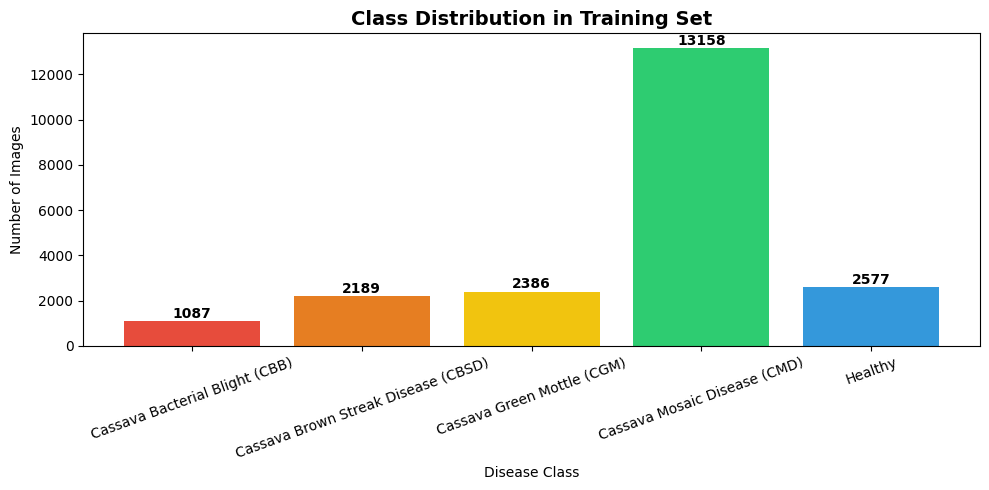


Class counts:
  [0] Cassava Bacterial Blight (CBB): 1087 (5.1%)
  [1] Cassava Brown Streak Disease (CBSD): 2189 (10.2%)
  [2] Cassava Green Mottle (CGM): 2386 (11.2%)
  [3] Cassava Mosaic Disease (CMD): 13158 (61.5%)
  [4] Healthy: 2577 (12.0%)


In [8]:
# Cell 5: Load & explore data

# Load training CSV
train_df = pd.read_csv(CFG.train_csv)
print(f'Train samples: {len(train_df)}')
print(train_df.head())

# Load label map
with open(CFG.label_map_path, 'r') as f:
    label_map = json.load(f)
# Keys are strings; convert to int for easy lookup
label_map = {int(k): v for k, v in label_map.items()}
print('\nLabel map:')
for k, v in label_map.items():
    print(f'  {k}: {v}')

# Class distribution
class_counts = train_df['label'].value_counts().sort_index()
class_names = [label_map[i] for i in class_counts.index]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(class_names, class_counts.values,
              color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db'])
ax.set_title('Class Distribution in Training Set', fontsize=14, fontweight='bold')
ax.set_xlabel('Disease Class')
ax.set_ylabel('Number of Images')
ax.tick_params(axis='x', rotation=20)

for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 30,
            str(count),
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print('\nClass counts:')
for i, (name, count) in enumerate(zip(class_names, class_counts.values)):
    print(f'  [{i}] {name}: {count} ({100*count/len(train_df):.1f}%)')

## Exploratory Data Analysis (EDA)

Before training, we inspect sample images from each class to:
- Understand visual characteristics of each disease
- Assess image quality and variability
- Inform augmentation strategy

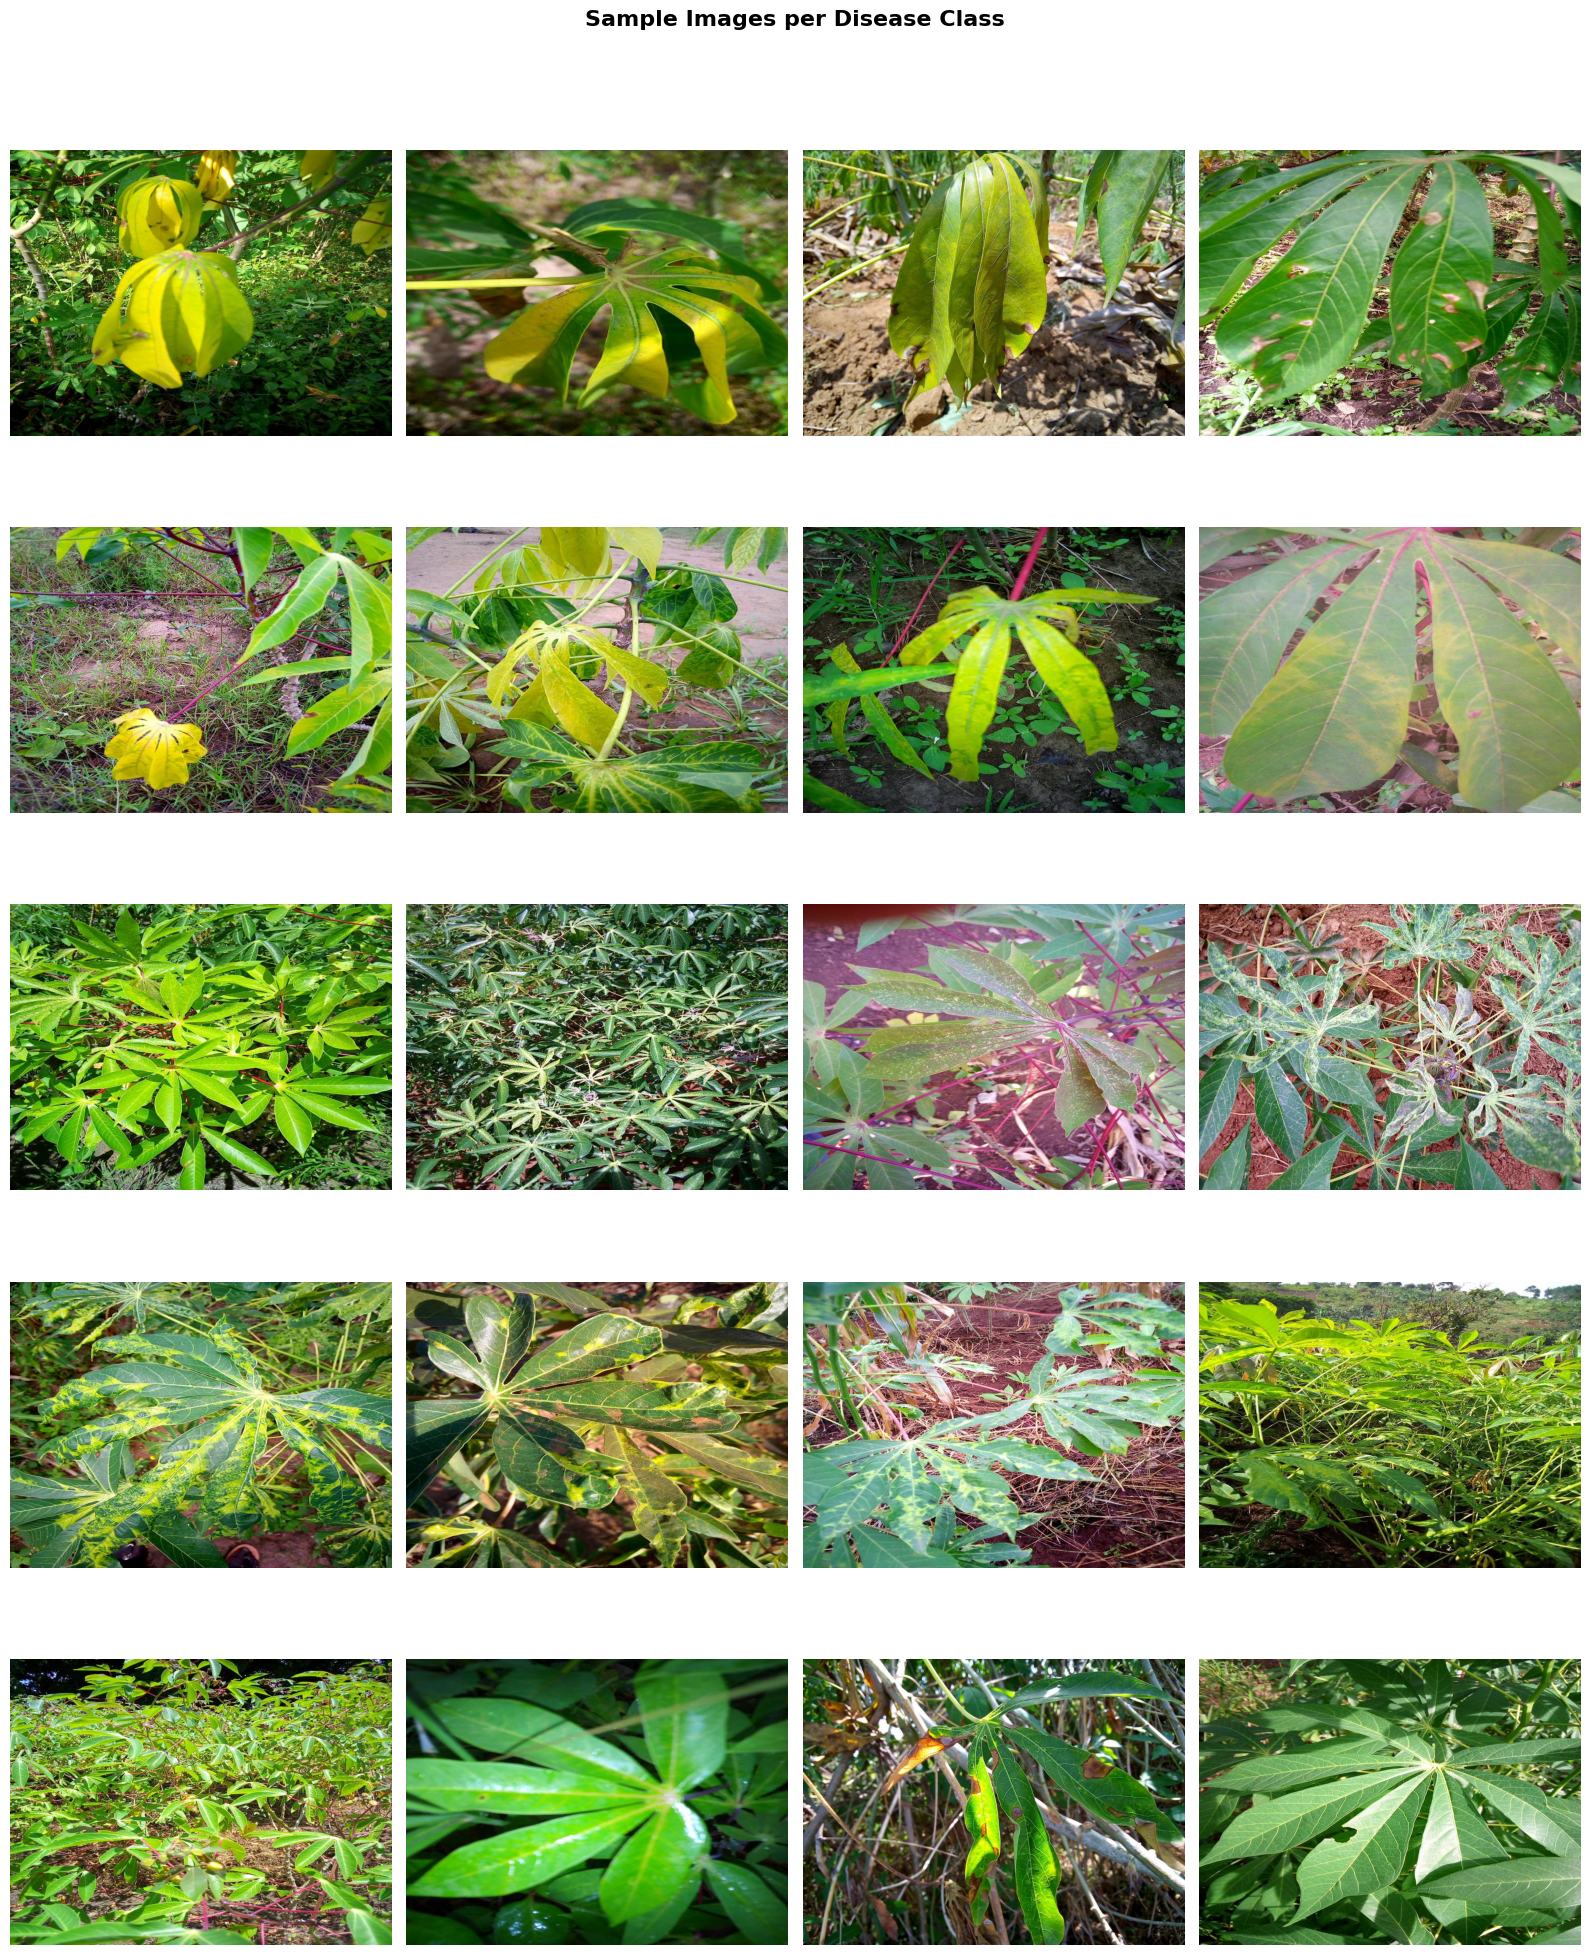

In [9]:
# Cell 7: EDA â€” visualize sample images per class
n_samples = 4
fig, axes = plt.subplots(CFG.num_classes, n_samples,
                         figsize=(4 * n_samples, 4 * CFG.num_classes))

for cls_idx in range(CFG.num_classes):
    cls_df = train_df[train_df['label'] == cls_idx].sample(n_samples, random_state=CFG.seed)
    for col, (_, row) in enumerate(cls_df.iterrows()):
        img_path = os.path.join(CFG.train_images, row['image_id'])
        img = mpimg.imread(img_path)
        axes[cls_idx, col].imshow(img)
        axes[cls_idx, col].axis('off')
        if col == 0:
            axes[cls_idx, col].set_ylabel(
                f'[{cls_idx}] {label_map[cls_idx]}',
                fontsize=10, fontweight='bold', rotation=0,
                labelpad=120, va='center'
            )

fig.suptitle('Sample Images per Disease Class', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [10]:
# Cell 8: Define Albumentations transforms
def get_train_transforms():
    return A.Compose([
        A.Resize(CFG.img_size, CFG.img_size),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.Rotate(limit=30, p=0.5),
        A.ColorJitter(
            brightness=0.2, contrast=0.2,
            saturation=0.2, hue=0.1, p=0.5
        ),
        A.OneOf([
            A.GaussNoise(var_limit=(10.0, 50.0), p=1.0),
            A.GaussianBlur(blur_limit=(3, 7), p=1.0),
        ], p=0.3),
        A.Normalize(mean=CFG.mean, std=CFG.std),
        ToTensorV2(),
    ])

def get_val_transforms():
    return A.Compose([
        A.Resize(CFG.img_size, CFG.img_size),
        A.Normalize(mean=CFG.mean, std=CFG.std),
        ToTensorV2(),
    ])

def get_test_transforms():
    return A.Compose([
        A.Resize(CFG.img_size, CFG.img_size),
        A.Normalize(mean=CFG.mean, std=CFG.std),
        ToTensorV2(),
    ])

print('Transforms defined.')
print(f'  Train augmentations: HFlip, VFlip, Rotate, ColorJitter, Noise/Blur')
print(f'  Val/Test: Resize + Normalize only')

Transforms defined.
  Train augmentations: HFlip, VFlip, Rotate, ColorJitter, Noise/Blur
  Val/Test: Resize + Normalize only


In [11]:
# Cell 9: CassavaDataset
class CassavaDataset(Dataset):
    """Custom PyTorch Dataset for Cassava Leaf Disease images."""

    def __init__(self, df, img_dir, transform=None, is_test=False):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['image_id'])

        # Read image as numpy array (H, W, C) in RGB
        image = np.array(Image.open(img_path).convert('RGB'))

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']  # Tensor (C, H, W)

        if self.is_test:
            return image

        label = torch.tensor(row['label'], dtype=torch.long)
        return image, label


print('CassavaDataset class defined.')

CassavaDataset class defined.


In [12]:
# Cell 10: Build DataLoaders with StratifiedKFold split
skf = StratifiedKFold(n_splits=CFG.num_folds, shuffle=True, random_state=CFG.seed)

# Add fold column to dataframe
train_df['fold'] = -1
for fold_idx, (_, val_idx) in enumerate(skf.split(train_df, train_df['label'])):
    train_df.loc[val_idx, 'fold'] = fold_idx

print(f'Fold distribution:')
for f in range(CFG.num_folds):
    n = (train_df['fold'] == f).sum()
    print(f'  Fold {f}: {n} samples')

# Split for selected fold
fold_train_df = train_df[train_df['fold'] != CFG.fold].reset_index(drop=True)
fold_val_df   = train_df[train_df['fold'] == CFG.fold].reset_index(drop=True)
print(f'\nUsing fold {CFG.fold}:')
print(f'  Train: {len(fold_train_df)} | Val: {len(fold_val_df)}')

# Datasets
train_dataset = CassavaDataset(fold_train_df, CFG.train_images, transform=get_train_transforms())
val_dataset   = CassavaDataset(fold_val_df,   CFG.train_images, transform=get_val_transforms())

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CFG.batch_size,
    shuffle=True,
    num_workers=CFG.num_workers,
    pin_memory=True,
    drop_last=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=CFG.batch_size,
    shuffle=False,
    num_workers=CFG.num_workers,
    pin_memory=True,
)

print(f'  Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Fold distribution:
  Fold 0: 4280 samples
  Fold 1: 4280 samples
  Fold 2: 4279 samples
  Fold 3: 4279 samples
  Fold 4: 4279 samples

Using fold 0:
  Train: 17117 | Val: 4280
  Train batches: 1069 | Val batches: 268


## Model Architecture

We use **EfficientNet-B4** loaded from `timm` with ImageNet pretrained weights. The classifier head is replaced with a single linear layer mapping to 5 output classes.

EfficientNet-B4 was chosen because:
- Native resolution of 380Ã—380 matches our image size
- Strong accuracy/efficiency trade-off
- Proven performance on similar plant disease benchmarks

In [13]:
# Cell 12: Model definition via timm
def build_model(model_name=CFG.model_name, num_classes=CFG.num_classes, pretrained=CFG.pretrained):
    model = timm.create_model(model_name, pretrained=pretrained)

    # Get the number of features in the classifier head
    if hasattr(model, 'classifier'):
        num_features = model.classifier.in_features
        model.classifier = nn.Linear(num_features, num_classes)
    elif hasattr(model, 'fc'):
        num_features = model.fc.in_features
        model.fc = nn.Linear(num_features, num_classes)
    else:
        # timm EfficientNet uses 'classifier'
        num_features = model.get_classifier().in_features
        model.reset_classifier(num_classes)

    return model


model = build_model()
model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model: {CFG.model_name}')
print(f'  Total parameters    : {total_params:,}')
print(f'  Trainable parameters: {trainable_params:,}')

Model: efficientnet_b4
  Total parameters    : 17,557,581
  Trainable parameters: 17,557,581


In [14]:
# Cell 13: Loss function
criterion = nn.CrossEntropyLoss(label_smoothing=CFG.label_smoothing)
print(f'Loss: CrossEntropyLoss with label_smoothing={CFG.label_smoothing}')
print('Label smoothing helps prevent overconfidence and improves calibration,')
print('which is beneficial given the class imbalance in this dataset.')

Loss: CrossEntropyLoss with label_smoothing=0.1
Label smoothing helps prevent overconfidence and improves calibration,
which is beneficial given the class imbalance in this dataset.


In [15]:
# Cell 14: Optimizer + Scheduler
optimizer = optim.AdamW(
    model.parameters(),
    lr=CFG.lr,
    weight_decay=CFG.weight_decay
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CFG.num_epochs,
    eta_min=1e-6
)

print(f'Optimizer : AdamW (lr={CFG.lr}, weight_decay={CFG.weight_decay})')
print(f'Scheduler : CosineAnnealingLR (T_max={CFG.num_epochs}, eta_min=1e-6)')

Optimizer : AdamW (lr=0.0001, weight_decay=1e-05)
Scheduler : CosineAnnealingLR (T_max=10, eta_min=1e-6)


## Training

The training loop:
1. Iterates over epochs, calling `train_one_epoch` then `validate_one_epoch`
2. Steps the LR scheduler after each epoch
3. Saves the best model checkpoint based on validation accuracy
4. Logs loss and accuracy for both splits

In [16]:
# Cell 16: train_one_epoch()
def train_one_epoch(model, loader, criterion, optimizer, device, epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc=f'Epoch {epoch+1} [Train]', leave=False)
    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        pbar.set_postfix({'loss': f'{loss.item():.4f}',
                          'acc':  f'{correct/total:.4f}'})

    epoch_loss = running_loss / total
    epoch_acc  = correct / total
    return epoch_loss, epoch_acc


print('train_one_epoch() defined.')

train_one_epoch() defined.


In [17]:
# Cell 17: validate_one_epoch()
def validate_one_epoch(model, loader, criterion, device, epoch):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc=f'Epoch {epoch+1} [Val]  ', leave=False)
    with torch.no_grad():
        for images, labels in pbar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            pbar.set_postfix({'loss': f'{loss.item():.4f}',
                              'acc':  f'{correct/total:.4f}'})

    epoch_loss = running_loss / total
    epoch_acc  = correct / total
    return epoch_loss, epoch_acc


print('validate_one_epoch() defined.')

validate_one_epoch() defined.


In [18]:
# Cell 18: Main training loop
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   []
}

best_val_acc = 0.0
best_model_path = os.path.join(CFG.output_dir, f'best_model_fold{CFG.fold}.pth')

print(f'Starting training for {CFG.num_epochs} epochs...\n')
print(f'{"Epoch":>5} | {"Train Loss":>10} | {"Train Acc":>9} | {"Val Loss":>8} | {"Val Acc":>7} | {"LR":>10}')
print('-' * 65)

for epoch in range(CFG.num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device, epoch)
    val_loss,   val_acc   = validate_one_epoch(model, val_loader, criterion, device, epoch)

    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'{epoch+1:>5} | {train_loss:>10.4f} | {train_acc:>9.4f} | {val_loss:>8.4f} | {val_acc:>7.4f} | {current_lr:>10.2e}')

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f'         --> New best model saved! Val Acc: {best_val_acc:.4f}')

print(f'\nTraining complete. Best Val Acc: {best_val_acc:.4f}')

Starting training for 10 epochs...

Epoch | Train Loss | Train Acc | Val Loss | Val Acc |         LR
-----------------------------------------------------------------


    1 |     0.9221 |    0.7396 |   0.7119 |  0.8453 |   9.76e-05
         --> New best model saved! Val Acc: 0.8453


    2 |     0.7598 |    0.8192 |   0.6836 |  0.8619 |   9.05e-05
         --> New best model saved! Val Acc: 0.8619


    3 |     0.7258 |    0.8351 |   0.6537 |  0.8764 |   7.96e-05
         --> New best model saved! Val Acc: 0.8764


    4 |     0.6940 |    0.8517 |   0.6545 |  0.8752 |   6.58e-05


...

    6 |     0.6632 |    0.8674 |   0.6485 |  0.8799 |   3.52e-05
         --> New best model saved! Val Acc: 0.8799


    7 |     0.6456 |    0.8759 |   0.6494 |  0.8799 |   2.14e-05


    8 |     0.6355 |    0.8810 |   0.6483 |  0.8815 |   1.05e-05
         --> New best model saved! Val Acc: 0.8815


    9 |     0.6287 |    0.8843 |   0.6533 |  0.8792 |   3.42e-06


   10 |     0.6271 |    0.8844 |   0.6506 |  0.8827 |   1.00e-06
         --> New best model saved! Val Acc: 0.8827

Training complete. Best Val Acc: 0.8827


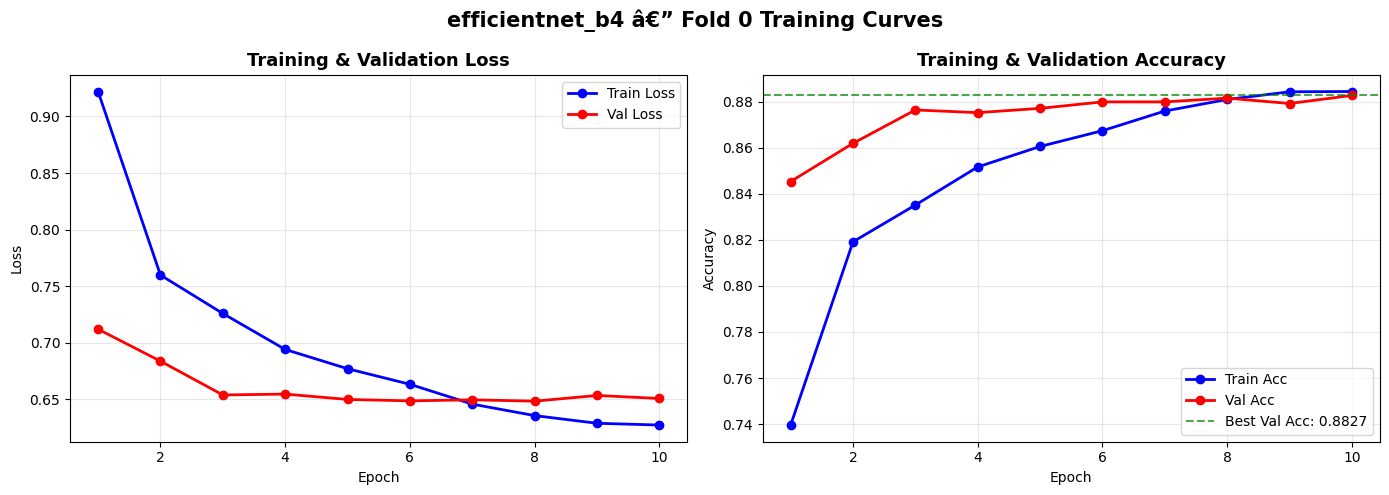

In [19]:
# Cell 19: Plot training curves
epochs_range = range(1, CFG.num_epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', linewidth=2)
ax1.plot(epochs_range, history['val_loss'],   'r-o', label='Val Loss',   linewidth=2)
ax1.set_title('Training & Validation Loss', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(epochs_range, history['train_acc'], 'b-o', label='Train Acc', linewidth=2)
ax2.plot(epochs_range, history['val_acc'],   'r-o', label='Val Acc',   linewidth=2)
ax2.axhline(y=best_val_acc, color='green', linestyle='--', alpha=0.7,
            label=f'Best Val Acc: {best_val_acc:.4f}')
ax2.set_title('Training & Validation Accuracy', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle(f'{CFG.model_name} â€” Fold {CFG.fold} Training Curves',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Inference

Load the best checkpoint saved during training, run inference on the test set, and write `submission.csv`.

In [20]:
# Cell 21: Load best model checkpoint
inference_model = build_model()
inference_model.load_state_dict(torch.load(best_model_path, map_location=device))
inference_model = inference_model.to(device)
inference_model.eval()

print(f'Loaded best model from: {best_model_path}')
print(f'Best validation accuracy: {best_val_acc:.4f}')

Loaded best model from: Z:/SUTD-Academic/Term 8/ComputerVision/CompetitionProject\best_model_fold0.pth
Best validation accuracy: 0.8827


In [21]:
# Cell 22: Run inference on test set
test_df = pd.read_csv(CFG.sample_submission)
print(f'Test samples: {len(test_df)}')
print(test_df.head())

test_dataset = CassavaDataset(
    test_df,
    CFG.test_images,
    transform=get_test_transforms(),
    is_test=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=CFG.batch_size,
    shuffle=False,
    num_workers=CFG.num_workers,
    pin_memory=True,
)

all_preds = []

with torch.no_grad():
    for images in tqdm(test_loader, desc='Inference'):
        images = images.to(device, non_blocking=True)
        outputs = inference_model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)

print(f'\nInference complete. Predictions: {len(all_preds)}')
unique, counts = np.unique(all_preds, return_counts=True)
print('Prediction distribution:')
for cls, cnt in zip(unique, counts):
    print(f'  [{cls}] {label_map[cls]}: {cnt}')

Test samples: 1
         image_id  label
0  2216849948.jpg      4


Inference: 100%|██████████| 1/1 [00:00<00:00,  4.61it/s]


Inference complete. Predictions: 1
Prediction distribution:
  [4] Healthy: 1


In [22]:
# Cell 23: Create submission.csv
submission_df = pd.DataFrame({
    'image_id': test_df['image_id'],
    'label': all_preds
})

submission_path = os.path.join(CFG.output_dir, 'submission.csv')
submission_df.to_csv(submission_path, index=False)

print(f'Submission saved to: {submission_path}')
print(f'Shape: {submission_df.shape}')
print(submission_df.head(10))

# Sanity check
assert len(submission_df) == len(test_df), 'Row count mismatch!'
assert submission_df['label'].between(0, 4).all(), 'Invalid label values!'
print('\nSanity checks passed. Ready to submit!')

Submission saved to: Z:/SUTD-Academic/Term 8/ComputerVision/CompetitionProject\submission.csv
Shape: (1, 2)
         image_id  label
0  2216849948.jpg      4

Sanity checks passed. Ready to submit!
